In [ ]:
!pip install git+https://github.com/pycaret/pycaret.git@master

  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-x0qy4j0d
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-x0qy4j0d
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pmdarima to determine which version is compatible with other 

In [ ]:
# numpy and pandas will be used for data manipulation
import numpy as np
import pandas as pd
# matplotlib will be used for visually representing our data
import matplotlib.pyplot as plt
# Yfinance will be used for importing historical oil prices
import yfinance as yfin

In [ ]:
# Setting our ticker
ticker = 'AMZN'
ticker = yfin.Ticker(ticker)


# Importing our data
data = ticker.history(period='5y')

<Axes: xlabel='Date', ylabel='Crude Oil Prices: Brent - Europe'>

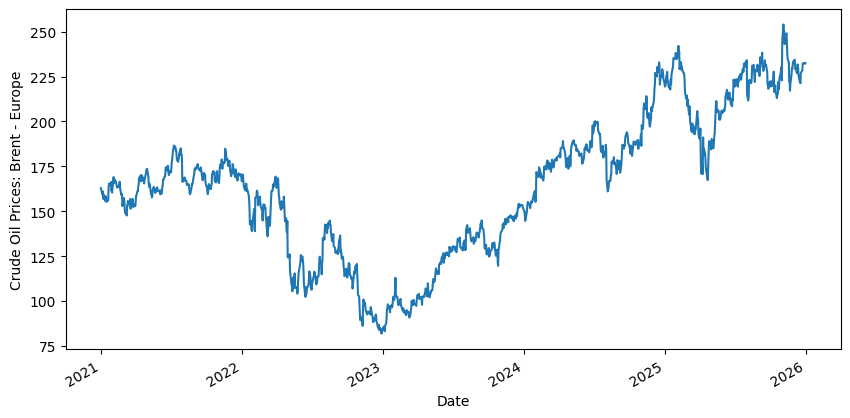

In [ ]:
# Setting the text on the Y-axis
plt.ylabel("Crude Oil Prices: Brent - Europe")

# Setting the size of our graph
data['Close'].plot(figsize=(10,5))

In [ ]:
data['SMA_20'] = data['Close'].shift(1).rolling(window=20).mean()
data['SMA_50']= data['Close'].shift(1).rolling(window=50).mean()
data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()

In [ ]:
data.head(20)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,SMA_50,EMA_20
Date,,,,,,,,,,
2020-12-31 00:00:00-05:00,163.750000,164.145996,162.059998,162.846497,59144000,0.0,0.0,NaN,NaN,162.846497
2021-01-04 00:00:00-05:00,163.500000,163.600006,157.201004,159.331497,88228000,0.0,0.0,NaN,NaN,162.511735
2021-01-05 00:00:00-05:00,158.300507,161.169006,158.253006,160.925507,53110000,0.0,0.0,NaN,NaN,162.360665
2021-01-06 00:00:00-05:00,157.324005,159.875504,156.557999,156.919006,87896000,0.0,0.0,NaN,NaN,161.842412
2021-01-07 00:00:00-05:00,157.850006,160.427002,157.750000,158.108002,70290000,0.0,0.0,NaN,NaN,161.486754
2021-01-08 00:00:00-05:00,159.000000,159.531998,157.110001,159.134995,70754000,0.0,0.0,NaN,NaN,161.262777
2021-01-11 00:00:00-05:00,157.400497,157.819000,155.500000,155.710495,73668000,0.0,0.0,NaN,NaN,160.733988
2021-01-12 00:00:00-05:00,156.000000,157.106995,154.300003,156.041504,70292000,0.0,0.0,NaN,NaN,160.287085
2021-01-13 00:00:00-05:00,156.421997,159.497498,156.104004,158.294495,66424000,0.0,0.0,NaN,NaN,160.097314


In [ ]:
# Dropping the NaN values
data = data.dropna()

# Initialising X and assigning the two feature variables
X = data[['EMA_20','SMA_50']]

# Getting the head of the data
X.head()

,EMA_20,SMA_50
Date,,
2021-03-16 00:00:00-04:00,155.482796,159.65225
2021-03-17 00:00:00-04:00,155.606958,159.48718
2021-03-18 00:00:00-04:00,155.206248,159.43628
2021-03-19 00:00:00-04:00,155.067368,159.24576
2021-03-22 00:00:00-04:00,155.112714,159.18234


In [ ]:
# Dropping the NaN values
data = data.dropna()

# Initialising X and assigning the two feature variables
X = data[['SMA_20','EMA_20','SMA_50', 'Close']]

# Getting the head of the data
X.head()

,SMA_20,EMA_20,SMA_50,Close
Date,,,,
2021-03-16 00:00:00-04:00,156.053701,155.482796,159.65225,154.593002
2021-03-17 00:00:00-04:00,155.610976,155.606958,159.48718,156.786499
2021-03-18 00:00:00-04:00,155.178701,155.206248,159.43628,151.399506
2021-03-19 00:00:00-04:00,154.428101,155.067368,159.24576,153.748001
2021-03-22 00:00:00-04:00,153.990752,155.112714,159.18234,155.543503


In [ ]:
# Setting the training set to 80% of the data
training = 0.7
t = int(training*len(X))

# Training dataset
data_train= X[:t]

# Testing dataset
data_test = X[t:]

In [ ]:
from pycaret.regression import *
s = setup(
    data=data[['SMA_20','SMA_50','EMA_20','Close']],
    target='Close',
    session_id=123,
    numeric_features=['SMA_20','SMA_50','EMA_20'],
    fold_strategy='timeseries', # Ensures temporal integrity
    data_split_shuffle=False,     # Prevents random shuffling
    n_jobs=-1
)

,Description,Value
0,Session id,123
1,Target,Close
2,Target type,Regression
3,Original data shape,"(1205, 4)"
4,Transformed data shape,"(1205, 4)"
5,Transformed train set shape,"(843, 4)"
6,Transformed test set shape,"(362, 4)"
7,Numeric features,3
8,Preprocess,True
9,Imputation type,simple


In [ ]:
# Create a Linear Regression model
lr = create_model('lr')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.5346,10.6179,3.2585,0.7337,0.0187,0.0149
1,2.9109,13.1875,3.6315,0.8925,0.0230,0.0181
2,4.3146,28.0398,5.2953,0.9309,0.0380,0.0317
3,3.7977,22.1654,4.7080,0.8449,0.0395,0.0317
4,3.0134,15.2110,3.9001,0.8976,0.0392,0.0307
5,1.3668,3.0295,1.7405,0.8421,0.0169,0.0136
6,1.7767,5.1321,2.2654,0.9309,0.0174,0.0139
7,2.6879,10.8336,3.2915,0.8163,0.0247,0.0201
8,2.0975,6.5536,2.5600,0.9494,0.0158,0.0129


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
tuned_lr = tune_model(lr)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.9327,6.5512,2.5595,0.8357,0.0148,0.0113
1,2.9272,13.4004,3.6606,0.8908,0.0232,0.0182
2,3.9909,24.2538,4.9248,0.9402,0.0348,0.0287
3,3.7040,21.5529,4.6425,0.8492,0.0390,0.0310
4,3.0085,15.1775,3.8958,0.8979,0.0392,0.0306
5,1.3659,3.0503,1.7465,0.8410,0.0170,0.0136
6,1.8057,5.2573,2.2929,0.9292,0.0177,0.0141
7,2.7035,10.9025,3.3019,0.8151,0.0247,0.0202
8,2.0588,6.4086,2.5315,0.9505,0.0156,0.0127


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 2 candidates, totalling 20 fits


In [ ]:
models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.Elast...,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPu...,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


In [ ]:
rf = create_model('rf')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,10.6139,143.3746,11.9739,-2.5953,0.0688,0.0636
1,4.8793,54.8704,7.4075,0.5529,0.0473,0.0313
2,21.5927,780.8202,27.9432,-0.9238,0.2044,0.1781
3,12.6414,216.1081,14.7006,-0.5117,0.1175,0.0997
4,15.6981,327.7746,18.1045,-1.2056,0.1791,0.1718
5,8.6051,91.9345,9.5882,-3.7923,0.0981,0.0849
6,7.3795,88.7154,9.4189,-0.1941,0.0775,0.0583
7,7.5518,79.7896,8.9325,-0.3529,0.0657,0.0542
8,4.4567,26.4635,5.1443,0.7957,0.0308,0.0269


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
tuned_rf = tune_model(rf)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,9.5493,123.2058,11.0998,-2.0895,0.0640,0.0573
1,4.9521,53.5902,7.3205,0.5633,0.0468,0.0317
2,20.8654,748.0342,27.3502,-0.8430,0.2008,0.1727
3,12.5411,219.1156,14.8026,-0.5328,0.1182,0.0983
4,16.6731,375.3491,19.3739,-1.5257,0.1903,0.1831
5,8.5444,88.8467,9.4259,-3.6313,0.0963,0.0843
6,6.3362,70.8633,8.4180,0.0462,0.0695,0.0501
7,7.4785,79.6693,8.9258,-0.3509,0.0651,0.0534
8,3.5788,17.9043,4.2313,0.8618,0.0254,0.0216


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [ ]:
print(tuned_rf)

RandomForestRegressor(n_jobs=-1, random_state=123)


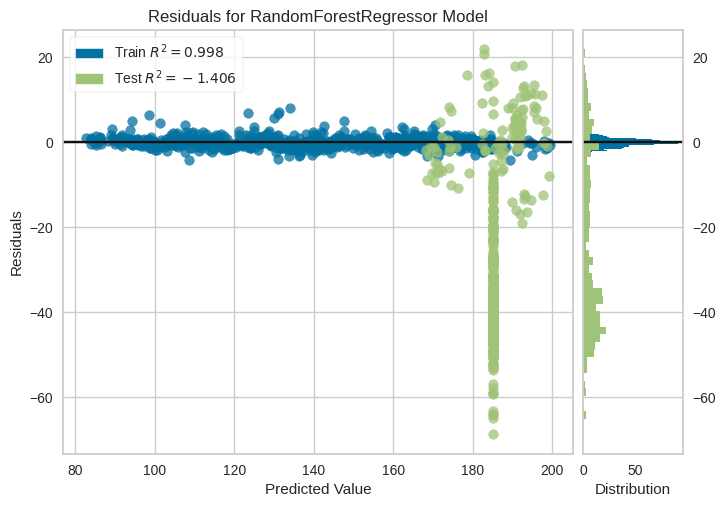

In [ ]:
plot_model(tuned_rf)

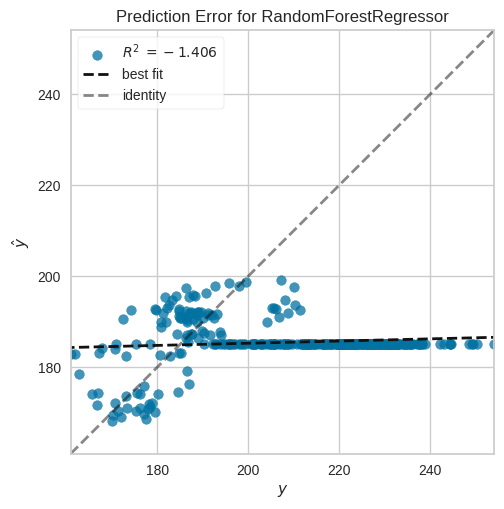

In [ ]:
plot_model(tuned_rf, plot = 'error')

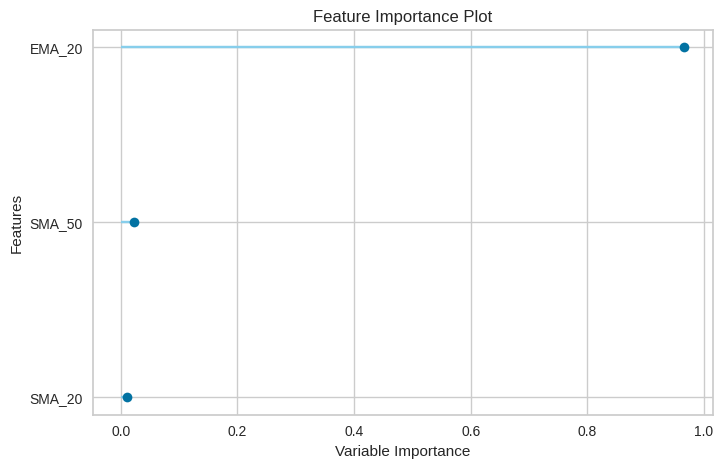

In [ ]:
plot_model(tuned_rf, plot = 'feature')

In [ ]:
evaluate_model(tuned_rf)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
predict_model(tuned_rf)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,27.1746,1037.6931,32.2132,-1.4058,0.1561,0.1228


,SMA_20,SMA_50,EMA_20,Close,prediction_label
Date,,,,,
2024-07-23 00:00:00-04:00,193.123505,187.558807,189.963409,186.410004,190.943401
2024-07-24 00:00:00-04:00,193.165497,187.496994,189.093552,180.830002,188.869900
2024-07-25 00:00:00-04:00,192.889999,187.363998,188.213211,179.850006,192.637101
2024-07-26 00:00:00-04:00,192.201996,187.229599,187.669098,182.500000,193.731402
2024-07-29 00:00:00-04:00,191.434494,187.138199,187.243469,183.199997,194.788302
...,...,...,...,...,...
2025-12-23 00:00:00-05:00,228.481003,229.507996,228.329666,232.139999,185.192799
2025-12-24 00:00:00-05:00,228.774002,229.749405,228.715408,232.380005,185.192799
2025-12-26 00:00:00-05:00,228.909500,230.069199,229.077759,232.520004,185.192799


In [ ]:
final_rf = finalize_model(tuned_rf)

In [ ]:
print(final_rf)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['SMA_20', 'SMA_50', 'EMA_20'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=[],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('actual_estimator',
                 RandomForestRegressor(n_jobs=-1, random_state=123))])


In [ ]:
predict_model(final_rf)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,1.2256,3.0332,1.7416,0.9930,0.0085,0.0059


,SMA_20,SMA_50,EMA_20,Close,prediction_label
Date,,,,,
2024-07-23 00:00:00-04:00,193.123505,187.558807,189.963409,186.410004,185.764003
2024-07-24 00:00:00-04:00,193.165497,187.496994,189.093552,180.830002,182.685502
2024-07-25 00:00:00-04:00,192.889999,187.363998,188.213211,179.850006,181.416104
2024-07-26 00:00:00-04:00,192.201996,187.229599,187.669098,182.500000,182.327400
2024-07-29 00:00:00-04:00,191.434494,187.138199,187.243469,183.199997,183.026199
...,...,...,...,...,...
2025-12-23 00:00:00-05:00,228.481003,229.507996,228.329666,232.139999,230.232400
2025-12-24 00:00:00-05:00,228.774002,229.749405,228.715408,232.380005,231.755204
2025-12-26 00:00:00-05:00,228.909500,230.069199,229.077759,232.520004,232.045904


In [ ]:
unseenrf_predictions = predict_model(final_rf, data=data_test)
unseenrf_predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,1.2256,3.0332,1.7416,0.9930,0.0085,0.0059


,SMA_20,EMA_20,SMA_50,Close,prediction_label
Date,,,,,
2024-07-23 00:00:00-04:00,193.123505,189.963409,187.558807,186.410004,185.764003
2024-07-24 00:00:00-04:00,193.165497,189.093552,187.496994,180.830002,182.685502
2024-07-25 00:00:00-04:00,192.889999,188.213211,187.363998,179.850006,181.416104
2024-07-26 00:00:00-04:00,192.201996,187.669098,187.229599,182.500000,182.327400
2024-07-29 00:00:00-04:00,191.434494,187.243469,187.138199,183.199997,183.026199
...,...,...,...,...,...
2025-12-23 00:00:00-05:00,228.481003,228.329666,229.507996,232.139999,230.232400
2025-12-24 00:00:00-05:00,228.774002,228.715408,229.749405,232.380005,231.755204
2025-12-26 00:00:00-05:00,228.909500,229.077759,230.069199,232.520004,232.045904


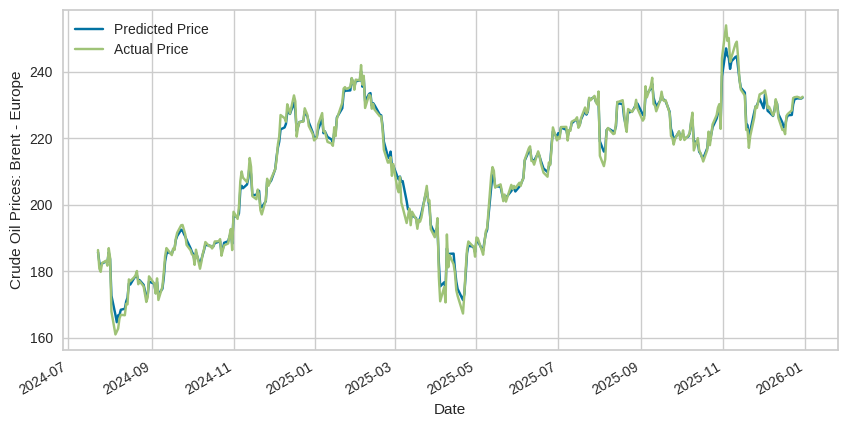

In [ ]:
predictedrf_price = pd.DataFrame(unseenrf_predictions,index=unseenrf_predictions.index,columns = ['prediction_label'])
predictedrf_price.plot(figsize=(10,5))
unseenrf_predictions['Close'].plot()
plt.legend(['Predicted Price','Actual Price'])
plt.ylabel("Crude Oil Prices: Brent - Europe")
plt.show()